Name: B Lohith Krishnan

Roll Number: CH.SC.U4CSE24153

Department: CSE

Section: B

# Exercise 1: Graduate Admission Prediction using Logistic Regression

A researcher is interested in how variables such as GRE, GPA and prestige of the undergraduate institution effect admission into graduate school. The response variable (admit/don't admit) is binary.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn

## Importing Dataset

In [2]:
col_names = ['sno', 'gre', 'toefl', 'rating', 'sop', 'lor', 'cg', 'research', 'chance']
df = pd.read_csv('../Data/Admission_Predict.csv', header=None, skiprows=1, names=col_names)
print(f"Shape: {df.shape}")
df.head()

Shape: (400, 9)


,sno,gre,toefl,rating,sop,lor,cg,research,chance
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


## Checking for any null values in dataset

In [3]:
df.isnull().sum()

sno         0
gre         0
toefl       0
rating      0
sop         0
lor         0
cg          0
research    0
chance      0
dtype: int64

## Assigning dependent and independent variables

Categorise chance >= 0.75 as 1 (admitted) since logistic regression expects categorical output.

In [4]:
feat_cols = ['gre', 'toefl', 'rating', 'sop', 'lor', 'cg', 'research']
x = df[feat_cols]
y = (df['chance'] >= 0.75).astype(int)

## Splitting the dataset into Training and Testing Dataset

In [5]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
display(xtrain.shape, xtest.shape, ytrain.shape, ytest.shape)

(320, 7)

(80, 7)

(320,)

(80,)

## Fitting the Model (Logistic Regression)

In [6]:
mdl = LogisticRegression(solver='lbfgs', max_iter=1000)

In [7]:
mdl.fit(xtrain, ytrain)
ypred = mdl.predict(xtest)

## Evaluation Metrics

In [8]:
conf_mat = metrics.confusion_matrix(ytest, ypred)
print('Confusion Matrix: ', conf_mat)
acc_score = metrics.accuracy_score(ytest, ypred)
print('Accuracy: ', acc_score)
print('Accuracy in percentage: ', int(acc_score * 100), '%')

Confusion Matrix:  [[43  4]
 [ 2 31]]
Accuracy:  0.925
Accuracy in percentage:  92 %


## Confusion Matrix Heatmap

<Axes: xlabel='Predicted', ylabel='Actual'>

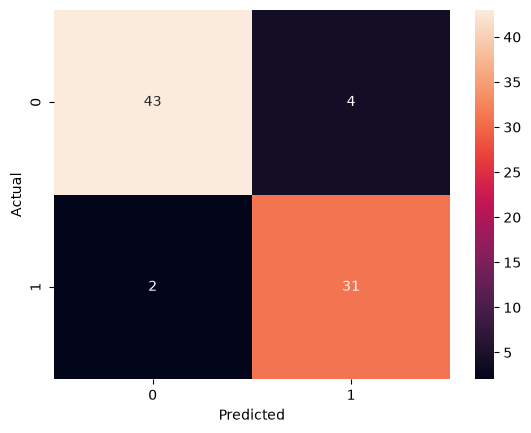

In [9]:
conf_mat = pd.crosstab(ytest, ypred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True)